In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

[*********************100%***********************]  2 of 2 completed


<Axes: xlabel='Date'>

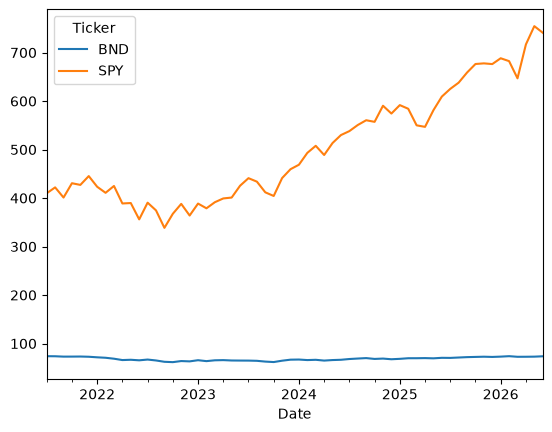

In [62]:
# 2 Tickers
hist = yf. download(tickers = ['SPY', 'BND'], period = '5y', interval = '1mo')['Close']
hist.dropna(inplace = True)
hist = hist.to_period('M')

hist.plot()

<Axes: xlabel='Date'>

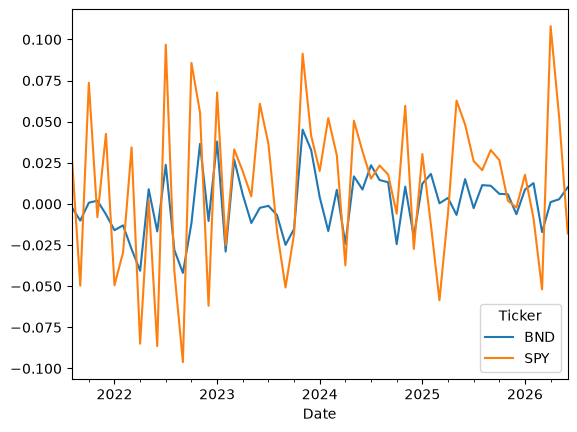

In [63]:
# Convert prices to returns
rets = hist.pct_change().dropna() # Return Series
rets.plot()

In [64]:
# Compound the entire return series
compound_returns = (1 + rets).prod() - 1
(compound_returns * 100).round(2).astype('str') + '%'

Ticker
BND    -0.28%
SPY     80.8%
dtype: str

In [65]:
# DataFrames
hist.head()                     # We can view first n elements 
hist.tail()                     # Can view end n elements

hist.size                       # Number of elements in DataFrame
hist.shape                      # Size of each individual axis
hist.index                      # Used to view y-axis
hist.columns                    # Used to view x-axis

hist['SPY']                     # Can index a stock to get a series
hist[['SPY']]                   # Index any number of columns to get DataFrame
hist.loc['2022-02']             # Index across rows 
hist.iloc[20]                   # Integer location given the position of an index

hist.loc['2022-02': '2022-08']  # Slicing also works with indexing
hist.iloc[20:24]


Ticker,BND,SPY
Date,,
2023-03,65.440117,391.452087
2023-04,65.811470,399.223419
2023-05,65.048782,401.066315
2023-06,64.894745,425.474792


In [66]:
# Measures of Risk
hist.std()                      # Standard Deviation

Ticker
BND      3.624149
SPY    114.799335
dtype: float64

In [67]:
# Annualized Returns
def annualize_rets(r, periods_per_year = 12):
    n_periods = r.shape[0]
    compounded_growth = (1 + r).prod()
    return compounded_growth ** (periods_per_year/n_periods) - 1

annualize_rets(hist)

Ticker
BND    1.230391e+22
SPY    1.974232e+32
dtype: float64

In [68]:
# Annualized Volatility
def annualize_vol(r, periods_per_year = 12):
    return r.std() * (periods_per_year ** 0.5)

annualize_vol(hist)

Ticker
BND     12.554422
SPY    397.676562
dtype: float64

In [69]:
# Raw Sharpe Ratio
annualize_rets(hist) / annualize_vol(hist)

Ticker
BND    9.800456e+20
SPY    4.964416e+29
dtype: float64

<Axes: xlabel='Date'>

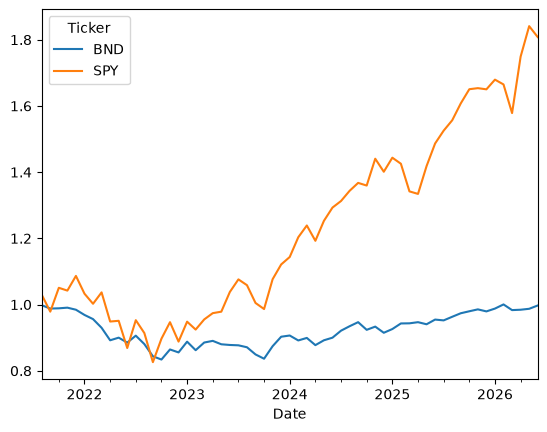

In [70]:
# Wealth Index
wealth_index = (1 + rets).cumprod()
wealth_index.plot()


In [71]:
rets = yf.download(tickers = 'SPY', period = '10y', interval = '1mo')['Close'].pct_change().dropna()

[*********************100%***********************]  1 of 1 completed


TypeError: unsupported format string passed to Series.__format__

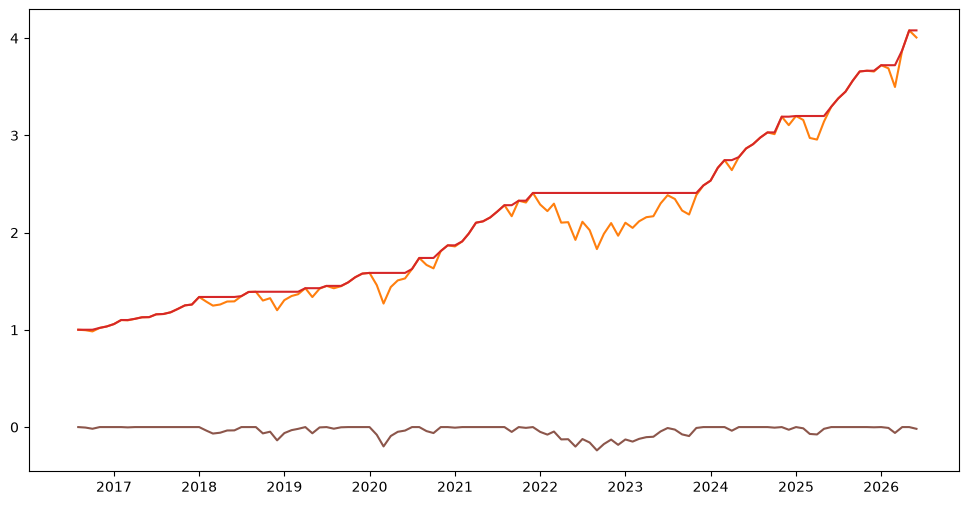

In [72]:
wealth_index = (1 + rets).cumprod()
start_date = wealth_index.index.min() - pd.DateOffset(months = 1)
wealth_index = pd.concat([pd.Series([1], index = [start_date]), wealth_index])

previous_peaks = wealth_index.cummax()
drawdowns = (wealth_index - previous_peaks) / previous_peaks

plt.figure(figsize=(12,6))
max_drawdown = drawdowns.min()
max_drawdown_date = drawdowns.idxmin()

plt.plot(wealth_index)
plt.plot(previous_peaks)
plt.plot(drawdowns)

plt.annotate(f'Max Drawdown: {max_drawdown:.2%}', xy= (max_drawdown_date, max_drawdown), 
             xytext = (max_drawdown_date + pd.DateOffset(years=2), max_drawdown * 2), 
             arrowprops = dict(arrowstyle = '->', lw=1), color='blue')